# NYC Housing Data Analysis 

#### <b> Overview </b>

A data analyzing class assignment demonstrating how to analyze and visualize NYC's housing data using Python libraries <b> (numpy, matplotlib, seaborn, folium, IPython.display) </b>

## <b> Imports </b>


In [65]:
import numpy as np                             # Linear algebra
import pandas as pd                            # Data processing/manipulation, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt                # Embedded in Jupyter Notebook
import seaborn as sns                          # Statistical data visualization
import folium                                  # Interactive maps
from IPython.display import display


In [66]:
sns.set_style('darkgrid')                     # Setting style for plots

## <b> Data Processing </b>

In [ ]:
# Load the dataset into a variable called df
df = pd.read_csv("NumPy\\new_york_housing\\NY-House-Dataset.csv")
df = df.sort_values('PRICE')



In [68]:
# Print column names to understand the dataset structure
print(df.columns) 
print(len(df))           # must be large
print(df.head())



Index(['BROKERTITLE', 'TYPE', 'PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT',
       'ADDRESS', 'STATE', 'MAIN_ADDRESS', 'ADMINISTRATIVE_AREA_LEVEL_2',
       'LOCALITY', 'SUBLOCALITY', 'STREET_NAME', 'LONG_NAME',
       'FORMATTED_ADDRESS', 'LATITUDE', 'LONGITUDE'],
      dtype='object')
4801
                              BROKERTITLE            TYPE  PRICE  BEDS  \
317   Brokered by Living NY - Main Office        For sale   2494     2   
310   Brokered by Living NY - Main Office        For sale   3225     3   
360   Brokered by Century 21 Realty First   Land for sale   5800     3   
463  Brokered by Morris Park Realty Group  Co-op for sale  49500     3   
979                   Brokered by COMPASS  Condo for sale  60000     3   

         BATH  PROPERTYSQFT                      ADDRESS                STATE  \
317  1.000000   2184.207862        635 W 170th St Apt 4F   New York, NY 10032   
310  1.000000   2184.207862        635 W 170th St Apt 2C   New York, NY 10032   
360  2.373861   2184.207

#### Cleaning

In [69]:
# Drop missing values
df = df.dropna(subset=["LATITUDE", "LONGITUDE", "PRICE", "PROPERTYSQFT"])

# Remove invalid entries
df = df[(df["PRICE"] > 0) & (df["PROPERTYSQFT"] > 0)]


Important to remove outliers before analysing

#### Price Bins 

In [70]:
# Create a new column for price per square foot (which will be used for visualizations)
df["price_per_sqft"] = df["PRICE"] / df["PROPERTYSQFT"]
df = df[df["price_per_sqft"] < 35000]
print(df[["LATITUDE", "LONGITUDE", "PRICE", "PROPERTYSQFT", "price_per_sqft"]].head())
print("Min Price per Sqft:", df["price_per_sqft"].min())
print("Max Price per Sqft:", df["price_per_sqft"].max())

# Price Bins 
bins = [1.14, 292.55, 416.67, 583.66, 966.38, 27469.91]
df["price_bin"] = pd.cut(df["price_per_sqft"], bins=bins, labels=[0,1,2,3,4])

# Print bin ranges
for i in range(len(bins) - 1):
    print(f"Bin {i}: ${bins[i]:.2f} - ${bins[i+1]:.2f}")

# Display the structure of the dataset and the first 10 rows 
df.info()
df.head(10)
# Check the dimensions (rows, columns) of the dataset
df.shape
# Summarize the dataset using descriptive statistics
df.describe()



      LATITUDE  LONGITUDE  PRICE  PROPERTYSQFT  price_per_sqft
317  40.843406 -73.940795   2494   2184.207862        1.141833
310  40.843406 -73.940795   3225   2184.207862        1.476508
360  40.618915 -73.931211   5800   2184.207862        2.655425
463  40.843284 -73.784603  49500    800.000000       61.875000
979  40.761398 -73.974613  60000    445.000000      134.831461
Min Price per Sqft: 1.1418327181170085
Max Price per Sqft: 27469.913026070775
Bin 0: $1.14 - $292.55
Bin 1: $292.55 - $416.67
Bin 2: $416.67 - $583.66
Bin 3: $583.66 - $966.38
Bin 4: $966.38 - $27469.91
<class 'pandas.core.frame.DataFrame'>
Index: 4800 entries, 317 to 1
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   BROKERTITLE                  4800 non-null   object  
 1   TYPE                         4800 non-null   object  
 2   PRICE                        4800 non-null   int64   
 3   BEDS              

,PRICE,BEDS,BATH,PROPERTYSQFT,LATITUDE,LONGITUDE,price_per_sqft
count,4.800000e+03,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000
mean,1.910039e+06,3.356042,2.373105,2182.579572,40.714268,-73.941542,778.469480
std,4.929167e+06,2.602054,1.946461,2374.709381,0.087639,0.101011,1171.638281
min,2.494000e+03,1.000000,0.000000,230.000000,40.499546,-74.253033,1.141833
25%,4.990000e+05,2.000000,1.000000,1200.000000,40.639512,-73.987143,323.903186
50%,8.250000e+05,3.000000,2.000000,2184.207862,40.726756,-73.949182,489.530730
75%,1.495000e+06,4.000000,3.000000,2184.207862,40.771924,-73.870638,822.599199
max,1.950000e+08,50.000000,50.000000,65535.000000,40.912729,-73.702450,27469.913026


## <b> Visualisation of Graphs </b>

#### Longitude vs Price per SQFT ScatterPlot  & Latitude vs Price per SQFT ScatterPlot

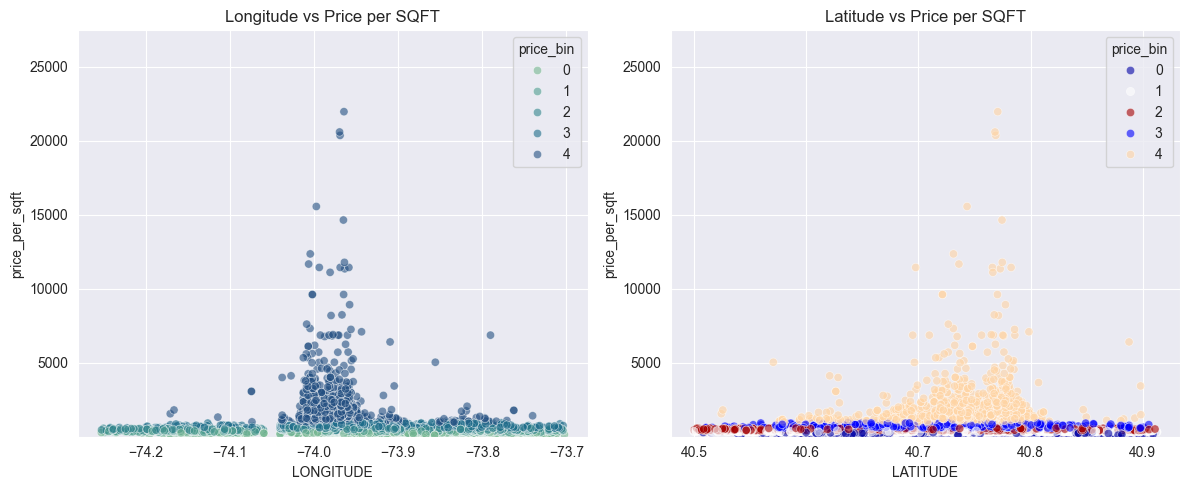

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Longitude plot
sns.scatterplot(                              # Seaborn used to enhance visuals
    x="LONGITUDE",
    y="price_per_sqft",
    hue="price_bin",
    palette="crest",
    data=df,
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_ylim(df["price_per_sqft"].min(), df["price_per_sqft"].max())         # Set a consistent y-axis limit for better comparison
axes[0].set_title("Longitude vs Price per SQFT")

# Latitude plot
sns.scatterplot(
    x="LATITUDE",
    y="price_per_sqft",
    hue="price_bin",
    palette="flag",
    data=df,
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_ylim(df["price_per_sqft"].min(), df["price_per_sqft"].max())
axes[1].set_title("Latitude vs Price per SQFT")

plt.tight_layout()
plt.show()


#### Latitude vs Longitude scatterplot 

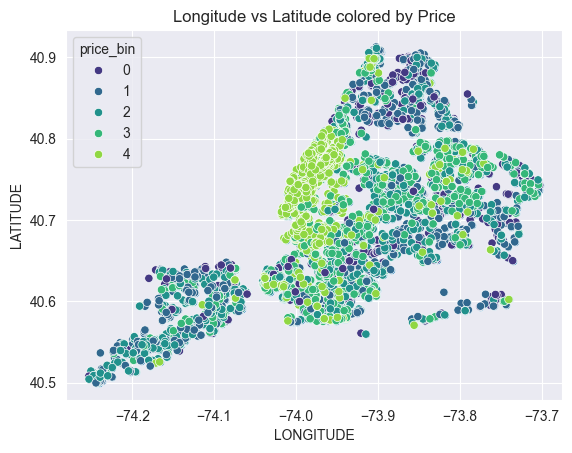

In [72]:
sns.scatterplot(x='LONGITUDE', y='LATITUDE', data=df) 
sns.scatterplot(x='LONGITUDE', y='LATITUDE', hue='price_bin', data=df, palette='viridis') # This color is lowkirkeknu
plt.title('Longitude vs Latitude colored by Price')
plt.show()   


## <b> Interactive Map </b>

The map will be made with the assistance of the folium library, and saved into the 
> <i> new_york_housing\\images\\nyc_housing_map.html </i> path

In [ ]:
# Create a base map centered around New York City
nyc_center = [df["LATITUDE"].mean(), df["LONGITUDE"].mean()]
m = folium.Map(location=nyc_center, zoom_start=10)
 
cheap_threshold = 300                                    
df_cheapest = df[df["price_per_sqft"] < cheap_threshold]

# Limit for performance
df_cheapest = df.sample(min(300, len(df_cheapest)), random_state=42)

# Add markers (limit for performance)

for _, row in df_cheapest.iterrows():
    
    # Color condition
    if row["price_per_sqft"] < cheap_threshold:
        color = "green"   # cheap
    else:
        color = "blue"    # others

    folium.CircleMarker(
        location=[row["LATITUDE"], row["LONGITUDE"]],
        radius=4,
        popup=f"${row['price_per_sqft']:.2f}/sqft",
        color=color,
        fill=True,
        fill_opacity=0.6
    ).add_to(m)
m # display map

Full Map Display: [Here](https://nbviewer.org/github/MHamzaS45/Data-Pipelines/blob/main/NumPy/new_york_housing/nyc_housing_da.ipynb)

In [ ]:
# Save map
m.save("NumPy/new_york_housing/images/nyc_housing_map.html")
print("Map saved as nyc_housing_map.html")

Map saved as nyc_housing_map.html
